Practical No:

Priyanka Jadhav

RollNo:13210(B1)

Assignment no.05
Problem Statement : Data Analytics II

Implement logistic regression using Python/R to perform classification on Social_Network_Ads.csv dataset.
Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [3]:
df.info

<bound method DataFrame.info of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [4]:
df.describe

<bound method NDFrame.describe of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [5]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[18, 30, 45, 60],
                        labels=['Young', 'Adult', 'Senior'])

print(df[['Age', 'Age_Group']].head())

   Age Age_Group
0   19     Young
1   35     Adult
2   26     Young
3   27     Young
4   19     Young


In [6]:
print(df.dtypes)

User ID               int64
Gender               object
Age                   int64
EstimatedSalary       int64
Purchased             int64
Age_Group          category
dtype: object


In [7]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased',
       'Age_Group'],
      dtype='object')

In [8]:
print(df.shape)

(400, 6)


In [9]:
print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
Age_Group          5
dtype: int64


In [10]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [11]:
df['Age'] = df['Age'].astype(int)

In [12]:
scaler = MinMaxScaler()
X = df[['Age', 'EstimatedSalary']]
X_scaled = scaler.fit_transform(X)
df_normalized = pd.DataFrame(X_scaled, columns=['Age', 'EstimatedSalary'])
print(df_normalized.head())

        Age  EstimatedSalary
0  0.023810         0.029630
1  0.404762         0.037037
2  0.190476         0.207407
3  0.214286         0.311111
4  0.023810         0.451852


In [13]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased,Age_Group
0,15624510,Male,19,19000,0,Young
1,15810944,Male,35,20000,0,Adult
2,15668575,Female,26,43000,0,Young
3,15603246,Female,27,57000,0,Young
4,15804002,Male,19,76000,0,Young
...,...,...,...,...,...,...
395,15691863,Female,46,41000,1,Senior
396,15706071,Male,51,23000,1,Senior
397,15654296,Female,50,20000,1,Senior
398,15755018,Male,36,33000,0,Adult


In [14]:
x = df.drop('Age',axis=1)

In [15]:
x = x.drop('Purchased', axis=1)

In [16]:
x

,User ID,Gender,EstimatedSalary,Age_Group
0,15624510,Male,19000,Young
1,15810944,Male,20000,Adult
2,15668575,Female,43000,Young
3,15603246,Female,57000,Young
4,15804002,Male,76000,Young
...,...,...,...,...
395,15691863,Female,41000,Senior
396,15706071,Male,23000,Senior
397,15654296,Female,20000,Senior
398,15755018,Male,33000,Adult


In [17]:
y = df['Purchased']

In [18]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0
Age_Group,5


In [19]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [20]:
X = df[['Age', 'EstimatedSalary']]   # input features
y = df['Purchased']                  # output (target)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [24]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.89


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8888888888888888
Recall: 0.75


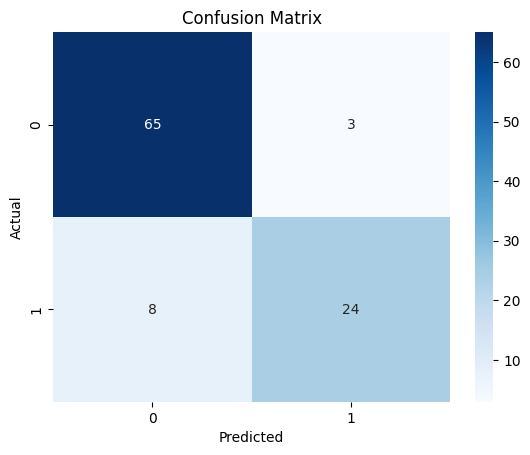

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()